# Foundation Model Embeddings For Niche Query

#### QueST

In [8]:
# load data
import os
import torch

def load_emb(adata_folder, emb_folder, emb_key):
    adata_list = []
    for fname in os.listdir(adata_folder):
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)
        if emb_key in adata.obs:
            print(f"[DONE] {stem}: {emb_key} exists in adata; loaded")
            continue

        emb_path = os.path.join(emb_folder, f"{stem}.pt")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        emb_tensor = torch.load(emb_path, map_location="cpu")
        emb = emb_tensor.detach().cpu().numpy()

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = 'data/'
emb_folder = 'data/QueST'
quest_embedding_key = 'quest_embedding'
adata_list = load_emb(adata_folder, emb_folder, emb_key=quest_embedding_key)

[LOAD] data/QueST/151675.pt
[DONE] 151675
[LOAD] data/QueST/151507.pt
[DONE] 151507
[LOAD] data/QueST/151510.pt
[DONE] 151510
[LOAD] data/QueST/151674.pt
[DONE] 151674
[LOAD] data/QueST/151669.pt
[DONE] 151669
[LOAD] data/QueST/151673.pt
[DONE] 151673
[LOAD] data/QueST/151672.pt
[DONE] 151672
[LOAD] data/QueST/151671.pt
[DONE] 151671
[LOAD] data/QueST/151670.pt
[DONE] 151670
[LOAD] data/QueST/151509.pt
[DONE] 151509
[LOAD] data/QueST/151676.pt
[DONE] 151676
[LOAD] data/QueST/151508.pt
[DONE] 151508


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/4132265828.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,


[<Axes: title={'center': '151675'}, xlabel='spatial1', ylabel='spatial2'>]

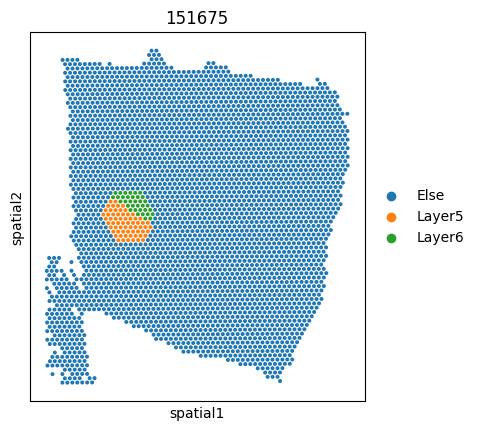

In [9]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns['library_id']
query_niche_id = 'Layer5_Layer6_100_replicate=0'
query_niche_mask = adata_list[0].obs[f'{query_niche_id}_niche'] == 'Niche'
sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,
              title=f"{adata_list[0].uns['library_id']}")

In [10]:
# niche query
from src.niche_emb_generator import NicheEmbGenerator

niche_embedding_key = 'quest_niche_embedding'
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(mask=query_niche_mask, embedding_key=quest_embedding_key,
                                                               adata=adata_list[0])
niche_emb_generator.generate_niche_embeddings(niche_embedding_key=niche_embedding_key,
                                              embedding_key=quest_embedding_key, coordinates_key='spatial', k=3,
                                              adata_list=adata_list)

[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151676
[DONE] finish adata: 151676
[START] start processing adata: 151508
[DONE] finish adata: 151508


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/2496700239.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/2496700239.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/2496700239.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/2496700239.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/2496700239.py:12: Future

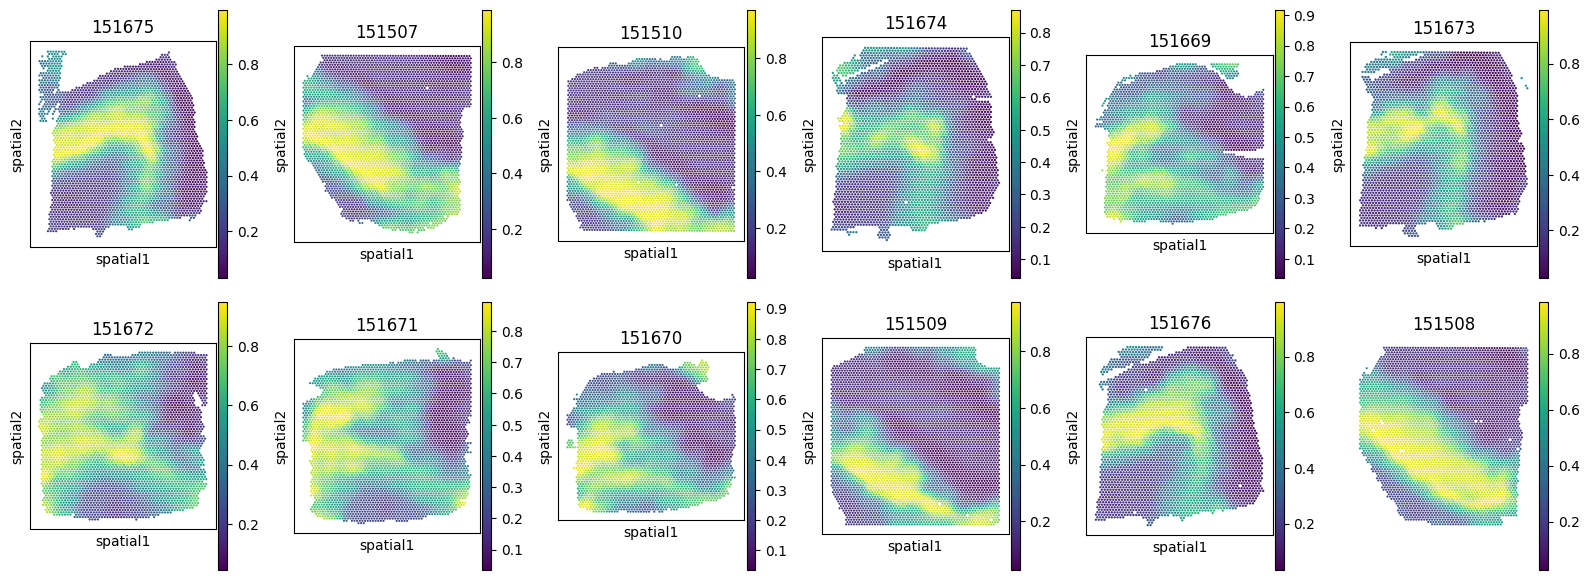

In [11]:
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

query_result_key = f'{query_niche_id}_query_result'
niche_query = NicheQuery()
adata_list = niche_query.query(adata_list, niche_embedding, query_result_key, niche_embedding_key)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
                  title=f"{adata.uns['library_id']}")
    axes[i].invert_yaxis()
axes[11].axis('off')
fig.tight_layout()
fig.show()

#### SToFM

In [1]:
# load data
import os
import numpy as np


def load_stofm_emb(adata_folder, emb_folder, emb_key):
    adata_list = []
    for fname in os.listdir(adata_folder):
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)
        if emb_key in adata.obs:
            print(f"[DONE] {stem}: {emb_key} exists in adata; loaded")
            continue

        npy_path = os.path.join(emb_folder, f"{stem}.npy")
        emb = np.load(npy_path)
        if not os.path.exists(npy_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {fname}")

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{npy_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = 'data/'
emb_folder = 'data/SToFM'
adata_list = load_stofm_emb(adata_folder, emb_folder, emb_key='stofm_embedding')

[LOAD] 151675.h5ad
[DONE] 151675
[LOAD] 151507.h5ad
[DONE] 151507
[LOAD] 151510.h5ad
[DONE] 151510
[LOAD] 151674.h5ad
[DONE] 151674
[LOAD] 151669.h5ad
[DONE] 151669
[LOAD] 151673.h5ad
[DONE] 151673
[LOAD] 151672.h5ad
[DONE] 151672
[LOAD] 151671.h5ad
[DONE] 151671
[LOAD] 151670.h5ad
[DONE] 151670
[LOAD] 151509.h5ad
[DONE] 151509
[LOAD] 151676.h5ad
[DONE] 151676
[LOAD] 151508.h5ad
[DONE] 151508


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/4132265828.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,


[<Axes: title={'center': '151675'}, xlabel='spatial1', ylabel='spatial2'>]

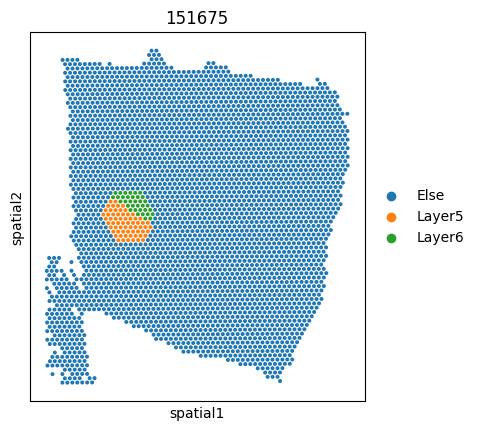

In [2]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns['library_id']
query_niche_id = 'Layer5_Layer6_100_replicate=0'
query_niche_mask = adata_list[0].obs[f'{query_niche_id}_niche'] == 'Niche'
sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,
              title=f"{adata_list[0].uns['library_id']}")

In [3]:
# niche query
from src.niche_emb_generator import NicheEmbGenerator

stofm_embedding_key = 'stofm_embedding'
niche_embedding_key = 'stofm_niche_embedding'
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(mask=query_niche_mask, embedding_key=stofm_embedding_key,
                                                               adata=adata_list[0])
niche_emb_generator.generate_niche_embeddings(niche_embedding_key=niche_embedding_key,
                                              embedding_key=stofm_embedding_key, coordinates_key='spatial', k=3,
                                              adata_list=adata_list)

[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151676
[DONE] finish adata: 151676
[START] start processing adata: 151508
[DONE] finish adata: 151508


In [4]:
from src.niche_query import NicheQuery

query_result_key = f'{query_niche_id}_query_result'
niche_query = NicheQuery()
adata_list = niche_query.query(adata_list, niche_embedding, query_result_key, niche_embedding_key)

/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/3658766772.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/3658766772.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/3658766772.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/3658766772.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_6406/3658766772.py:7: FutureWarni

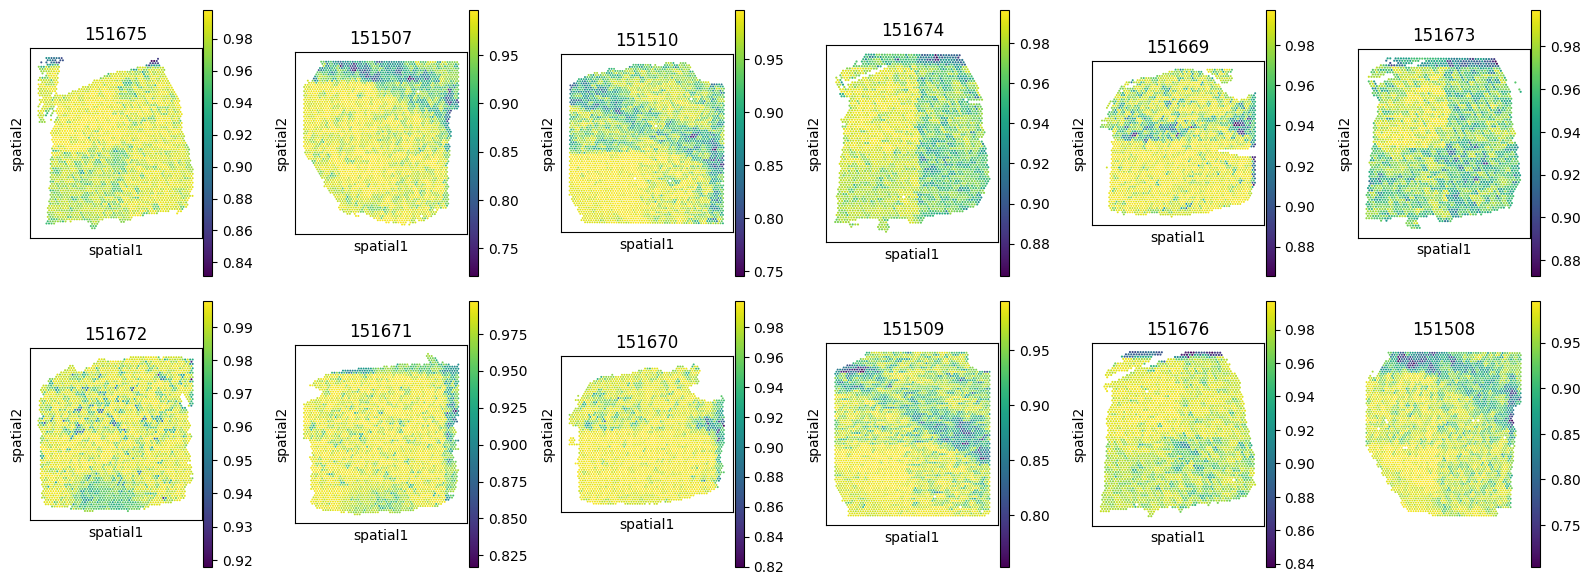

In [5]:
# visualize output
import matplotlib.pyplot as plt

fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
                  title=f"{adata.uns['library_id']}")
    axes[i].invert_yaxis()
axes[11].axis('off')
fig.tight_layout()
fig.show()

# Raw Gene Expression

In [2]:
# load data
import os
import pandas as pd
import scanpy as sc
import numpy as np
import torch

def load_emb(adata_folder, emb_key):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)
        # choose hvg
        adata.layers["counts"] = adata.X.copy()
        sc.pp.filter_cells(adata, min_genes=200)
        sc.pp.filter_genes(adata, min_cells=1)
        sc.pp.highly_variable_genes(
            adata,
            n_top_genes=2000,
            flavor="seurat_v3",
            subset=True
        )
        X_hvg = adata.X
        if not isinstance(X_hvg, np.ndarray):
            X_hvg = X_hvg.toarray()
        adata.obsm[emb_key] = X_hvg
        adata_list.append(adata)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = 'data/'
emb_key = 'X'
adata_list = load_emb(adata_folder, emb_key)

[DONE] 151507
[DONE] 151508
[DONE] 151509
[DONE] 151510
[DONE] 151669
[DONE] 151670
[DONE] 151671
[DONE] 151672
[DONE] 151673
[DONE] 151674
[DONE] 151675
[DONE] 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_1483/4132265828.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,


[<Axes: title={'center': '151507'}, xlabel='spatial1', ylabel='spatial2'>]

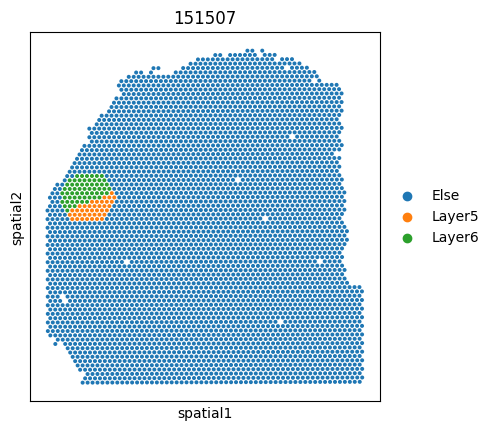

In [3]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns['library_id']
query_niche_id = 'Layer5_Layer6_100_replicate=0'
query_niche_mask = adata_list[0].obs[f'{query_niche_id}_niche'] == 'Niche'
sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,
              title=f"{adata_list[0].uns['library_id']}")

[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151508
[DONE] finish adata: 151508
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151676
[DONE] finish adata: 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_1483/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_1483/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_1483/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_1483/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_1483/4010131807.py:23: Future

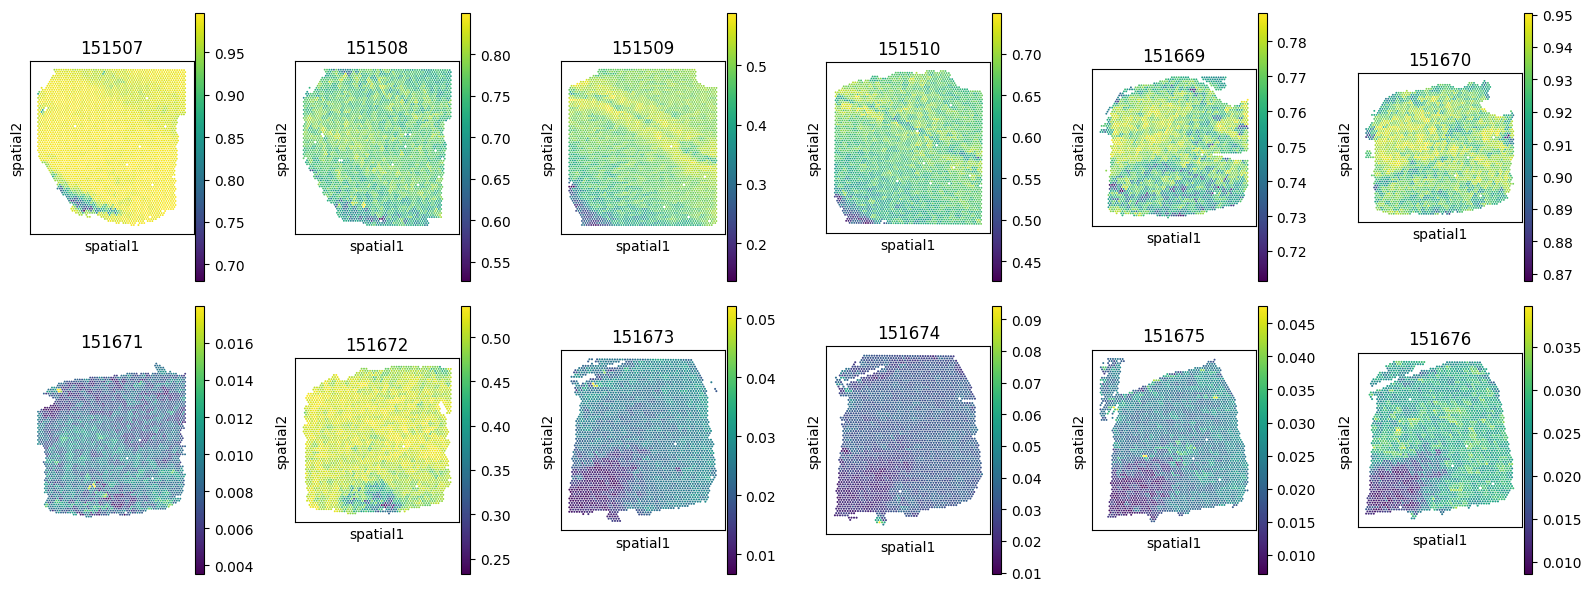

In [4]:
# niche query
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

from src.niche_emb_generator import NicheEmbGenerator

niche_embedding_key = f'{emb_key}_niche_embedding'
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(mask=query_niche_mask, embedding_key=emb_key,
                                                               adata=adata_list[0])
niche_emb_generator.generate_niche_embeddings(niche_embedding_key=niche_embedding_key,
                                              embedding_key=emb_key, coordinates_key='spatial', k=3,
                                              adata_list=adata_list)

query_result_key = f'{emb_key}_query_result'
niche_query = NicheQuery()
adata_list = niche_query.query(adata_list, niche_embedding, query_result_key, niche_embedding_key)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
                  title=f"{adata.uns['library_id']}")
    axes[i].invert_yaxis()
axes[6].axis('off')
fig.tight_layout()
fig.show()

# scGPT Embedding

In [5]:
# load data
import os
import pandas as pd
import scanpy as sc
import numpy as np
import torch

def load_emb(adata_folder, emb_folder, emb_key, suffix='pt', update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == 'csv':
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == 'pt':
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            raise ValueError(f"Unknown suffix {suffix}")

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = 'data/'
emb_folder = 'data/scGPT'
emb_key = 'X_scGPT'
adata_list = load_emb(adata_folder, emb_folder, emb_key=emb_key, suffix='csv')

[LOAD] data/scGPT/151507.csv
[DONE] 151507
[LOAD] data/scGPT/151508.csv
[DONE] 151508
[LOAD] data/scGPT/151509.csv
[DONE] 151509
[LOAD] data/scGPT/151510.csv
[DONE] 151510
[LOAD] data/scGPT/151669.csv
[DONE] 151669
[LOAD] data/scGPT/151670.csv
[DONE] 151670
[LOAD] data/scGPT/151671.csv
[DONE] 151671
[LOAD] data/scGPT/151672.csv
[DONE] 151672
[LOAD] data/scGPT/151673.csv
[DONE] 151673
[LOAD] data/scGPT/151674.csv
[DONE] 151674
[LOAD] data/scGPT/151675.csv
[DONE] 151675
[LOAD] data/scGPT/151676.csv
[DONE] 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_52157/4132265828.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,


[<Axes: title={'center': '151507'}, xlabel='spatial1', ylabel='spatial2'>]

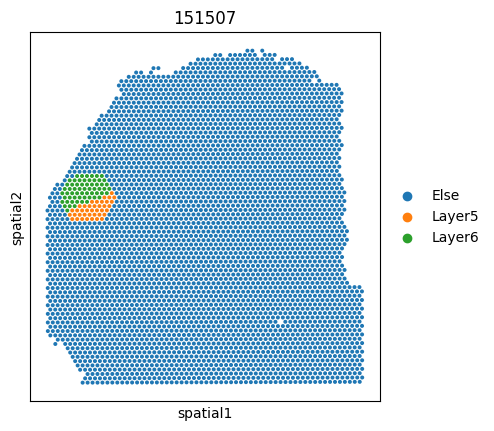

In [6]:
import scanpy as sc

# step 0: visualize query niche
query_sample_id = adata_list[0].uns['library_id']
query_niche_id = 'Layer5_Layer6_100_replicate=0'
query_niche_mask = adata_list[0].obs[f'{query_niche_id}_niche'] == 'Niche'
sc.pl.spatial(adata_list[0], color=f"{query_niche_id}_layer", spot_size=5, show=False,
              title=f"{adata_list[0].uns['library_id']}")

[START] start processing adata: 151507
[DONE] finish adata: 151507
[START] start processing adata: 151508
[DONE] finish adata: 151508
[START] start processing adata: 151509
[DONE] finish adata: 151509
[START] start processing adata: 151510
[DONE] finish adata: 151510
[START] start processing adata: 151669
[DONE] finish adata: 151669
[START] start processing adata: 151670
[DONE] finish adata: 151670
[START] start processing adata: 151671
[DONE] finish adata: 151671
[START] start processing adata: 151672
[DONE] finish adata: 151672
[START] start processing adata: 151673
[DONE] finish adata: 151673
[START] start processing adata: 151674
[DONE] finish adata: 151674
[START] start processing adata: 151675
[DONE] finish adata: 151675
[START] start processing adata: 151676
[DONE] finish adata: 151676


/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_52157/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_52157/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_52157/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_52157/4010131807.py:23: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
/var/folders/cb/yd_h3b5576d6wq5rydwp3_kr0000gn/T/ipykernel_52157/4010131807.py:23: F

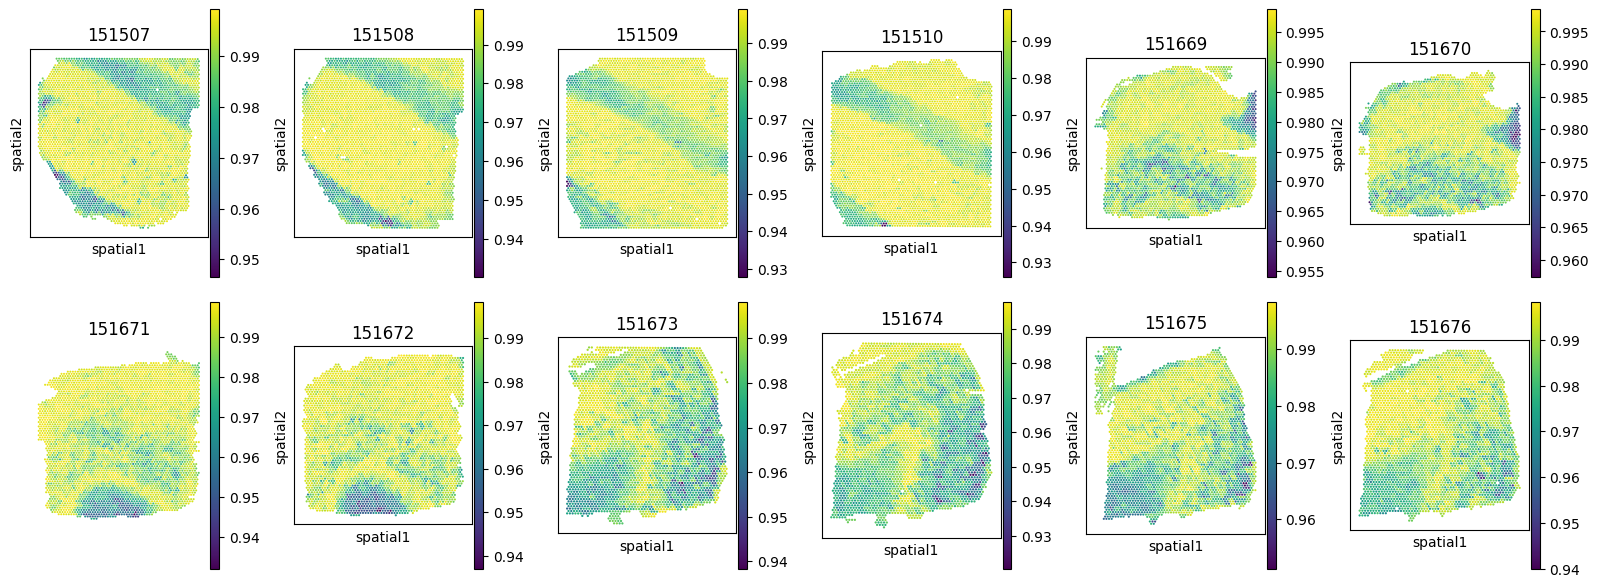

In [7]:
# niche query
from src.niche_query import NicheQuery
import matplotlib.pyplot as plt

from src.niche_emb_generator import NicheEmbGenerator

niche_embedding_key = f'{emb_key}_niche_embedding'
niche_emb_generator = NicheEmbGenerator()
niche_embedding = niche_emb_generator.generate_niche_embedding(mask=query_niche_mask, embedding_key=emb_key,
                                                               adata=adata_list[0])
niche_emb_generator.generate_niche_embeddings(niche_embedding_key=niche_embedding_key,
                                              embedding_key=emb_key, coordinates_key='spatial', k=3,
                                              adata_list=adata_list)

query_result_key = f'{emb_key}_query_result'
niche_query = NicheQuery()
adata_list = niche_query.query(adata_list, niche_embedding, query_result_key, niche_embedding_key)

# visualize output
fig, axes = plt.subplots(ncols=6, nrows=2, figsize=(16, 6))
axes = axes.flatten()
for i, adata in enumerate(adata_list):
    sc.pl.spatial(adata, color=f"{query_result_key}", ax=axes[i], show=False, spot_size=5,
                  title=f"{adata.uns['library_id']}")
    axes[i].invert_yaxis()
axes[6].axis('off')
fig.tight_layout()
fig.show()